# Malaysian E-Wallet & Banking Reviews — Preprocessing & Text-Based Sentiment Labelling

**Goal:** turn `data/reviews_raw.csv` into a clean, sentiment-labelled dataset.

**Key principle:** sentiment labels come from the **review TEXT** via a pre-trained
transformer sentiment model — **NOT** from star ratings. The `rating` column is kept for
reference only.

Pipeline: Inspect → Clean (EN / Bahasa Malaysia / Manglish aware) → Label with
`cardiffnlp/twitter-roberta-base-sentiment-latest` (English) → Engineer features → Save.


## Setup — imports & config

In [1]:
import os
import re
import json
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import emoji as emoji_lib

# Ensure required NLTK data is present (no-op if already downloaded)
for pkg in ["stopwords", "wordnet", "omw-1.4"]:
    try:
        nltk.data.find(f"corpora/{pkg}")
    except LookupError:
        nltk.download(pkg, quiet=True)

# Paths (notebook lives in notebooks/, data in ../data/)
ROOT = os.path.abspath("..")
RAW_PATH = os.path.join(ROOT, "data", "reviews_raw.csv")
OUT_PATH = os.path.join(ROOT, "data", "cleaned_data.csv")
DROPPED_PATH = os.path.join(ROOT, "data", "dropped_reviews.csv")

pd.set_option("display.max_colwidth", 120)
tqdm.pandas()
print("Setup complete.")

C:\Users\Iman\Desktop\project_2\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Setup complete.


## STEP 1 — Inspect the raw data
Understand structure, size, missingness, review-length distribution, and the
English / Malay / Manglish language mix before touching anything.

In [2]:
df_raw = pd.read_csv(RAW_PATH)
print("Shape:", df_raw.shape)
print("\nColumns & dtypes:")
print(df_raw.dtypes)

Shape: (18000, 8)

Columns & dtypes:
app_key              str
app_name             str
review_id            str
username             str
rating             int64
at                   str
content              str
thumbs_up_count    int64
dtype: object


In [3]:
# Sample of 10 rows
df_raw.sample(10, random_state=42)[["app_name", "rating", "at", "content"]]

,app_name,rating,at,content
2574,Maybank MAE,2,2023-05-20 11:33:47,The expense tracker may be a good idea and the UI design seems clean. But this is useless if I always have to close ...
7496,ShopeePay (Shopee MY),5,2025-10-23 13:22:35,good service
9210,BigPay,1,2019-02-20 16:22:10,having problems with trying to access my account saying unable to reach me and to check my connections what's wrong ...
5456,Boost eWallet,1,2019-06-13 16:32:03,Bad service because i already sent an email about the payment that have been transfer out from wallet to the maybank...
736,Touch 'n Go eWallet,3,2019-07-25 08:59:04,"The app is not bad but there is a major draw-back for tracking parking time. We know when we exit, but the app does ..."
11770,CIMB OCTO MY,1,2025-03-04 11:22:18,Hello. Why i always got error said the transaction cant go through due to i got other mobile login the same account?...
856,Touch 'n Go eWallet,3,2021-02-13 03:40:32,The app is great as a standard e wallet and I do find it more convenient to pay tolls with it so its a pretty good e...
7273,ShopeePay (Shopee MY),5,2026-01-09 18:16:04,sangat2 membantu bila tengah hujung bulan.. thank u
11499,CIMB OCTO MY,1,2024-10-13 13:07:01,Apps keeps crashing since latest update. Please fix this issue ASAP! This is banking apps! People need it to functio...
11605,CIMB OCTO MY,3,2023-09-10 07:41:45,Have issue with secure tac... everytime I want to log in I need to uninstall the app and reinstall it because if not...


In [4]:
# Row count per app
print("Reviews per app:")
print(df_raw["app_name"].value_counts())

# Missing values
print("\nMissing values per column:")
print(df_raw.isna().sum())

Reviews per app:
app_name
Touch 'n Go eWallet      2000
Maybank MAE              2000
Boost eWallet            2000
ShopeePay (Shopee MY)    2000
BigPay                   2000
CIMB OCTO MY             2000
RHB Banking App          2000
Hong Leong Connect       2000
MyPB by Public Bank      2000
Name: count, dtype: int64

Missing values per column:
app_key            0
app_name           0
review_id          0
username           1
rating             0
at                 0
content            0
thumbs_up_count    0
dtype: int64


Word-count distribution (raw content):
count    18000.000000
mean        42.022833
std         26.482878
min          1.000000
25%         21.000000
50%         39.000000
75%         60.000000
max        291.000000
Name: _wc, dtype: float64


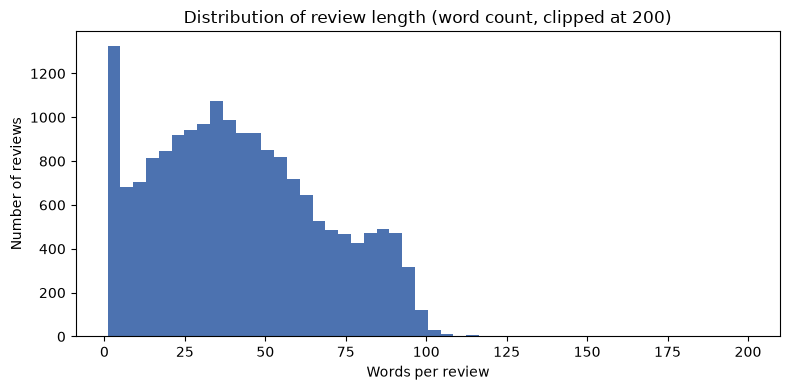

In [5]:
# Review length distribution (word count on raw content)
df_raw["_wc"] = df_raw["content"].fillna("").str.split().str.len()
print("Word-count distribution (raw content):")
print(df_raw["_wc"].describe())

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df_raw["_wc"].clip(upper=200), bins=50, color="#4C72B0")
ax.set_title("Distribution of review length (word count, clipped at 200)")
ax.set_xlabel("Words per review")
ax.set_ylabel("Number of reviews")
plt.tight_layout()
plt.show()

In [6]:
# Rough language-mix estimate using common Malay function words as a heuristic.
# A review is "Malay-present" if it contains >=1 of these tokens; if it ALSO contains
# enough ASCII English we treat it as likely code-mixed (Manglish).
MALAY_MARKERS = {
    "yang", "tak", "saya", "ni", "dgn", "dengan", "untuk", "tidak", "tu", "ini",
    "itu", "ada", "tak", "boleh", "tak", "sangat", "sgt", "byk", "banyak", "kalau",
    "macam", "mcm", "jadi", "dah", "nak", "kena", "guna", "kalo", "dgn", "lah",
}

def _lang_bucket(text):
    if not isinstance(text, str) or not text.strip():
        return "empty"
    toks = re.findall(r"[a-z']+", text.lower())
    if not toks:
        return "empty"
    n_malay = sum(t in MALAY_MARKERS for t in toks)
    malay_ratio = n_malay / len(toks)
    if n_malay == 0:
        return "english_only"
    # Has Malay markers. If a meaningful chunk is still non-marker words, call it code-mixed.
    if malay_ratio < 0.5 and len(toks) >= 4:
        return "code_mixed (Manglish)"
    return "malay_present"

lang = df_raw["content"].apply(_lang_bucket)
mix = (lang.value_counts(normalize=True) * 100).round(1)
print("Estimated language mix (heuristic, based on Malay function words):")
print(mix.astype(str) + " %")

Estimated language mix (heuristic, based on Malay function words):
content
english_only             97.7 %
code_mixed (Manglish)     2.0 %
malay_present             0.2 %
empty                     0.2 %
Name: proportion, dtype: str


## STEP 2 — Text cleaning pipeline

`clean_text()` handles English, Bahasa Malaysia, and Manglish. Order matters:

1. lowercase
2. convert sentiment emojis → words (**before** stripping the rest)
3. remove URLs / emails / @mentions; keep hashtag text, drop `#`
4. expand multi-word + single-word contractions (**before** tokenizing)
5. collapse 3+ repeated chars → 2 (`bagusss`→`baguss`)
6. strip remaining punctuation / leftover emoji
7. whitespace tokenize
8. remove EN+Malay stopwords — **but keep negation words** (they flip sentiment)
9. lemmatize with WordNet (Malay words aren't in WordNet, so they pass through
   unchanged — we deliberately do **not** stem Malay)

The dictionaries below are intentionally easy to extend.

In [7]:
# --- Extensible resources -------------------------------------------------

# Single-token contractions / shorthand -> full form
CONTRACTIONS = {
    "tak": "tidak", "x": "tidak", "dgn": "dengan", "yg": "yang", "tu": "itu",
    "ni": "ini", "sgt": "sangat", "byk": "banyak", "bgs": "bagus",
    "tq": "terima kasih", "tqvm": "terima kasih", "plz": "please", "pls": "please",
    "kalo": "kalau", "klu": "kalau", "jgn": "jangan", "utk": "untuk",
    "takleh": "tidak boleh", "mcm": "macam",
}

# Multi-word shorthand handled on the raw string before tokenizing
MULTIWORD_CONTRACTIONS = {
    "tk leh": "tidak boleh",
}

# Sentiment-bearing emojis -> words (applied BEFORE other emoji/punct stripping)
EMOJI_MAP = {
    "\U0001F621": "angry", "\U0001F620": "angry", "\U0001F4A2": "angry",
    "\U0001F92C": "angry", "\U0001F624": "angry",
    "\u2764\ufe0f": "love", "\u2764": "love", "\U0001F60D": "love",
    "\U0001F970": "love", "\U0001F618": "love", "\U0001F44D": "love",
    "\U0001F622": "sad", "\U0001F62D": "sad", "\U0001F614": "sad",
    "\U0001F61E": "sad",
    "\U0001F642": "happy", "\U0001F60A": "happy", "\U0001F600": "happy",
    "\U0001F601": "happy",
    "\U0001F44E": "dislike",
}

# Negations must NEVER be removed as stopwords (they flip sentiment)
NEGATIONS = {"tidak", "tak", "bukan", "jangan", "no", "not", "never", "dont", "don"}

# Curated static Bahasa Malaysia stopword list (negations deliberately excluded)
MALAY_STOPWORDS = {
    "ada", "adalah", "adanya", "agar", "akan", "aku", "al", "amat", "anda",
    "antara", "apa", "apabila", "apakah", "atau", "atas", "awak", "bagai",
    "bagaimana", "bagi", "bahawa", "bahwa", "banyak", "baru", "bawah",
    "beberapa", "begitu", "belum", "berada", "berapa", "beri", "bila", "bisa",
    "boleh", "buat", "dan", "dapat", "dari", "daripada", "dengan", "di", "dia",
    "dirinya", "dah", "hampir", "hanya", "hari", "harus", "ia", "iaitu",
    "ialah", "ini", "itu", "jadi", "jika", "juga", "kalau", "kami", "kamu",
    "kan", "kata", "ke", "kena", "kepada", "kerana", "kita", "lagi", "lain",
    "lalu", "macam", "maka", "masa", "masih", "mau", "melainkan", "memang",
    "mempunyai", "mengenai", "mereka", "mesti", "mungkin", "nak", "nanti",
    "oleh", "pada", "paling", "para", "pernah", "pula", "pun", "saat", "saja",
    "sahaja", "sama", "sambil", "sampai", "sangat", "satu", "saya", "se",
    "sebab", "sebagai", "sebuah", "secara", "sedang", "sehingga", "sejak",
    "sekarang", "selain", "selalu", "semua", "sendiri", "seperti", "sesuatu",
    "setiap", "siapa", "sini", "situ", "suatu", "sudah", "supaya", "tadi",
    "tahu", "tanpa", "tapi", "telah", "tentang", "terhadap", "terlalu",
    "tetapi", "tiap", "tu", "tuk", "untuk", "walau", "walaupun", "ya", "yaitu",
    "yang", "guna", "kalo",
}

EN_STOPWORDS = set(stopwords.words("english"))
# Combined stop set, then remove negations so they are always preserved
STOPWORDS = (EN_STOPWORDS | MALAY_STOPWORDS) - NEGATIONS

lemmatizer = WordNetLemmatizer()
print(f"Combined stopwords: {len(STOPWORDS)}  |  negations preserved: {sorted(NEGATIONS)}")

Combined stopwords: 335  |  negations preserved: ['bukan', 'don', 'dont', 'jangan', 'never', 'no', 'not', 'tak', 'tidak']


In [8]:
URL_RE = re.compile(r"http\S+|www\.\S+")
EMAIL_RE = re.compile(r"\S+@\S+")
MENTION_RE = re.compile(r"@\w+")
ELONG_RE = re.compile(r"(.)\1{2,}")          # 3+ repeats
NONALNUM_RE = re.compile(r"[^a-z0-9\s]")       # strips punctuation + leftover emoji

def clean_text(text):
    """Return a list of cleaned tokens for English / Malay / Manglish text."""
    if not isinstance(text, str):
        return []
    t = text.lower()

    # (e) sentiment emojis -> words, BEFORE stripping the rest
    for emo, word in EMOJI_MAP.items():
        if emo in t:
            t = t.replace(emo, f" {word} ")

    # (b) URLs, emails, mentions; keep hashtag text, drop '#'
    t = URL_RE.sub(" ", t)
    t = EMAIL_RE.sub(" ", t)
    t = MENTION_RE.sub(" ", t)
    t = t.replace("#", " ")

    # (d) multi-word contractions on the raw string
    for k, v in MULTIWORD_CONTRACTIONS.items():
        t = re.sub(r"\b" + re.escape(k) + r"\b", v, t)

    # (c) collapse elongated chars: 3+ -> 2 (keeps real double letters like "cool")
    t = ELONG_RE.sub(r"\1\1", t)

    # (b cont.) strip remaining punctuation + any leftover emoji
    t = NONALNUM_RE.sub(" ", t)

    # (f) whitespace tokenize
    tokens = t.split()

    # (d) single-token contractions (re-split: some expand to two words)
    tokens = " ".join(CONTRACTIONS.get(tok, tok) for tok in tokens).split()

    # (g) drop stopwords but always keep negations
    tokens = [tok for tok in tokens if tok in NEGATIONS or tok not in STOPWORDS]

    # (h) WordNet lemmatize; Malay words are absent from WordNet so pass through
    tokens = [lemmatizer.lemmatize(tok) for tok in tokens]
    return tokens

# Quick sanity check
for s in ["Bagusss app tapi tak boleh login lahhh 😡",
          "I LOVE this app!! so slowww though @support pls fix https://x.co/a"]:
    print(s, "\n  ->", clean_text(s), "\n")

Bagusss app tapi tak boleh login lahhh 😡 
  -> ['baguss', 'app', 'tidak', 'login', 'lahh', 'angry'] 

I LOVE this app!! so slowww though @support pls fix https://x.co/a 
  -> ['love', 'app', 'sloww', 'though', 'please', 'fix'] 



In [9]:
# Work on a copy; keep the original content column intact.
df = df_raw.drop(columns=["_wc"]).copy()
n_start = len(df)

# (j) Drop exact duplicate reviews early (on original content) to save compute.
df = df.drop_duplicates(subset=["content"]).reset_index(drop=True)
n_after_dupes = len(df)
print(f"Dropped {n_start - n_after_dupes} exact-duplicate reviews ({n_start} -> {n_after_dupes}).")

# Apply cleaning -> tokens + cleaned_text (original 'content' preserved).
df["tokens"] = df["content"].progress_apply(clean_text)
df["cleaned_text"] = df["tokens"].apply(lambda toks: " ".join(toks))

Dropped 558 exact-duplicate reviews (18000 -> 17442).



  0%|          | 0/17442 [00:00<?, ?it/s]


  5%|▌         | 924/17442 [00:00<00:01, 9165.99it/s]


 11%|█         | 1841/17442 [00:00<00:01, 8487.21it/s]


 16%|█▌        | 2723/17442 [00:00<00:01, 8607.75it/s]

...


 71%|███████   | 12355/17442 [00:01<00:00, 11013.15it/s]


 77%|███████▋  | 13470/17442 [00:01<00:00, 10681.89it/s]


 87%|████████▋ | 15143/17442 [00:01<00:00, 12345.50it/s]


 97%|█████████▋| 16832/17442 [00:01<00:00, 13635.37it/s]


100%|██████████| 17442/17442 [00:01<00:00, 11485.01it/s]

In [10]:
# (i) Reviews with < 3 tokens after cleaning -> dropped_reviews.csv for manual review.
short_mask = df["tokens"].str.len() < 3
dropped = df[short_mask].copy()
dropped["tokens"] = dropped["tokens"].apply(lambda x: " ".join(x))
dropped.to_csv(DROPPED_PATH, index=False, encoding="utf-8")
print(f"Dropped {len(dropped)} reviews with < 3 tokens -> {DROPPED_PATH}")

df = df[~short_mask].reset_index(drop=True)
n_after_short = len(df)
print(f"Rows remaining for labelling: {n_after_short}")

Dropped 560 reviews with < 3 tokens -> C:\Users\Iman\Desktop\project_2\data\dropped_reviews.csv
Rows remaining for labelling: 16882


## STEP 3 — Text-based sentiment labelling

**Model:** [`cardiffnlp/twitter-roberta-base-sentiment-latest`](https://huggingface.co/cardiffnlp/twitter-roberta-base-sentiment-latest)

**Why this model:** the language-mix check in Step 1 shows the corpus is **~97% English**,
so an English-specific model is the right fit — it understands casual, informal app-review
English better than a multilingual model that has to spread capacity across many languages.
This model was fine-tuned on ~124M English tweets and emits a native 3-class scheme
(positive / neutral / negative) that matches the project. The small Malay/Manglish remainder
is still handled gracefully because Bahasa Malaysia shares the Latin script and much
loan-word vocabulary.

Inference runs on the **original text** (transformers handle raw text better than the
aggressively cleaned version) and reports the softmax confidence per prediction.

In [11]:
import torch
from transformers import pipeline

device = 0 if torch.cuda.is_available() else -1
if device == -1:
    print("WARNING: No GPU detected. Running on CPU.")
    print(f"Expect roughly 20-40 minutes for {len(df)} reviews. This is normal.")
else:
    print("GPU detected — inference will be fast.")

clf = pipeline(
    "sentiment-analysis",
    model="cardiffnlp/twitter-roberta-base-sentiment-latest",
    device=device,
    truncation=True,
    max_length=512,
)
print("Model loaded.")

Expect roughly 20-40 minutes for 16882 reviews. This is normal.



Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 40151.22it/s]


[transformers] RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.bias   | UNEXPECTED |  | 
roberta.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded.


In [12]:
# Robust label normalisation (handles both 'label_0' and named outputs)
LABEL_FIX = {
    "label_0": "negative", "label_1": "neutral", "label_2": "positive",
    "negative": "negative", "neutral": "neutral", "positive": "positive",
}

texts = df["content"].astype(str).tolist()
labels, scores = [], []
BATCH = 32

for i in tqdm(range(0, len(texts), BATCH), desc="Labelling"):
    batch = texts[i:i + BATCH]
    for out in clf(batch, batch_size=BATCH):
        labels.append(LABEL_FIX.get(out["label"].lower(), out["label"].lower()))
        scores.append(float(out["score"]))

df["sentiment_label"] = labels
df["confidence_score"] = scores
print("Labelling done.")


Labelling:   0%|          | 0/528 [00:00<?, ?it/s]


Labelling:   0%|          | 1/528 [00:02<21:35,  2.46s/it]


Labelling:   0%|          | 2/528 [00:06<28:26,  3.24s/it]


Labelling:   1%|          | 3/528 [00:08<24:38,  2.82s/it]


Labelling:   1%|          | 4/528 [00:10<23:16,  2.67s/it]

...


Labelling: 100%|█████████▉| 526/528 [16:50<00:02,  1.28s/it]


Labelling: 100%|█████████▉| 527/528 [16:51<00:01,  1.34s/it]


Labelling: 100%|██████████| 528/528 [16:52<00:00,  1.04s/it]


Labelling: 100%|██████████| 528/528 [16:52<00:00,  1.92s/it]

Labelling done.


In [13]:
# Resulting class distribution (text-based, independent of star ratings)
print("Sentiment class distribution:")
print(df["sentiment_label"].value_counts())
print()
print((df["sentiment_label"].value_counts(normalize=True) * 100).round(1).astype(str) + " %")

Sentiment class distribution:
sentiment_label
negative    13068
positive     2740
neutral      1074
Name: count, dtype: int64

sentiment_label
negative    77.4 %
positive    16.2 %
neutral      6.4 %
Name: proportion, dtype: str


In [14]:
# Awareness only: how many low-confidence (< 0.6) predictions, with a few examples.
low = df[df["confidence_score"] < 0.6]
print(f"Low-confidence predictions (<0.6): {len(low)} ({len(low)/len(df)*100:.1f}%)")
low[["content", "sentiment_label", "confidence_score"]].head(5)

Low-confidence predictions (<0.6): 1394 (8.3%)


,content,sentiment_label,confidence_score
10,"I've been using the app for a while, and it was doing alright, especially for online payments. It WAS very useful an...",positive,0.509165
13,Pretty good use overall. Only two things which I think could improve on 1. I can't pay for parking for more thab 1 h...,neutral,0.428442
14,"How is it that if e wallet balance is low, the tng card can be deducted, yet you cannot transfer e wallet balance in...",neutral,0.586199
26,"The apps quite smooth and have many function. However, I notice some minor issues on the internet connection. I alwa...",neutral,0.508739
32,"I use this app for RFID toll & parking. It is very convenient for cashless transactions. However, some issues need t...",neutral,0.479393


## STEP 4 — Feature engineering

In [15]:
df["word_count_original"] = df["content"].astype(str).str.split().str.len()
df["word_count_cleaned"] = df["tokens"].str.len()
df["has_emoji"] = df["content"].astype(str).apply(lambda s: bool(emoji_lib.emoji_count(s)))
df["exclamation_count"] = df["content"].astype(str).str.count("!")
df["question_mark_count"] = df["content"].astype(str).str.count(r"\?")
df["char_count"] = df["content"].astype(str).str.len()

df[["word_count_original", "word_count_cleaned", "has_emoji",
    "exclamation_count", "question_mark_count", "char_count"]].describe(include="all")

,word_count_original,word_count_cleaned,has_emoji,exclamation_count,question_mark_count,char_count
count,16882.000000,16882.000000,16882,16882.000000,16882.000000,16882.000000
unique,NaN,NaN,2,NaN,NaN,NaN
top,NaN,NaN,False,NaN,NaN,NaN
freq,NaN,NaN,15856,NaN,NaN,NaN
mean,44.645184,25.524168,NaN,0.452257,0.317616,245.851558
std,25.190923,13.963459,NaN,1.498771,0.908886,136.236024
min,1.000000,3.000000,NaN,0.000000,0.000000,3.000000
25%,25.000000,15.000000,NaN,0.000000,0.000000,139.000000
50%,42.000000,24.000000,NaN,0.000000,0.000000,230.000000
75%,62.000000,35.000000,NaN,0.000000,0.000000,341.000000


## STEP 5 — Output, charts & summary

In [16]:
# Assemble final frame. 'rating' kept for REFERENCE only (never used as a label).
out = pd.DataFrame({
    "review_id": df["review_id"],
    "app_name": df["app_name"],
    "original_text": df["content"],
    "cleaned_text": df["cleaned_text"],
    "tokens": df["tokens"].apply(lambda x: " ".join(x)),   # space-joined for CSV
    "rating": df["rating"],
    "sentiment_label": df["sentiment_label"],
    "confidence_score": df["confidence_score"].round(4),
    "review_date": df["at"],
    "word_count_original": df["word_count_original"],
    "word_count_cleaned": df["word_count_cleaned"],
    "has_emoji": df["has_emoji"],
    "exclamation_count": df["exclamation_count"],
    "question_mark_count": df["question_mark_count"],
    "char_count": df["char_count"],
})
out.to_csv(OUT_PATH, index=False, encoding="utf-8")
print(f"Saved {len(out)} rows -> {OUT_PATH}")
out.head(3)

Saved 16882 rows -> C:\Users\Iman\Desktop\project_2\data\cleaned_data.csv


,review_id,app_name,original_text,cleaned_text,tokens,rating,sentiment_label,confidence_score,review_date,word_count_original,word_count_cleaned,has_emoji,exclamation_count,question_mark_count,char_count
0,8771a48a-2dc7-408b-979f-e6eb5b10c883,Touch 'n Go eWallet,Used to be my main ewallet. suddenly they dont allow quick payment and auto top up for debit. Such a disappointment....,used main ewallet suddenly dont allow quick payment auto top debit disappointment need lot extra step put money insi...,used main ewallet suddenly dont allow quick payment auto top debit disappointment need lot extra step put money insi...,1,negative,0.9089,2026-05-23 17:04:36,70,35,False,0,0,345
1,2e75abd6-e2cb-4f5d-a0e8-3e2a8fa2acfd,Touch 'n Go eWallet,"idk what's wrong with this e wallet. when i try to open the app, my phone crashes and i have to wait for almost 10 m...",idk wrong e wallet try open app phone crash wait almost 10 minute ton notification said system ui responding bla bla...,idk wrong e wallet try open app phone crash wait almost 10 minute ton notification said system ui responding bla bla...,2,negative,0.9361,2026-04-19 22:04:40,72,36,False,0,0,382
2,03ed8978-cafb-4313-8be0-8f2bc7420459,Touch 'n Go eWallet,The app works fine until yesterday. It starts to crash every time it's launched so that it becomes completely unusab...,app work fine yesterday start crash every time launched becomes completely unusable even reinstall clear cache anoth...,app work fine yesterday start crash every time launched becomes completely unusable even reinstall clear cache anoth...,3,negative,0.8056,2026-05-03 12:39:57,87,48,False,0,0,496


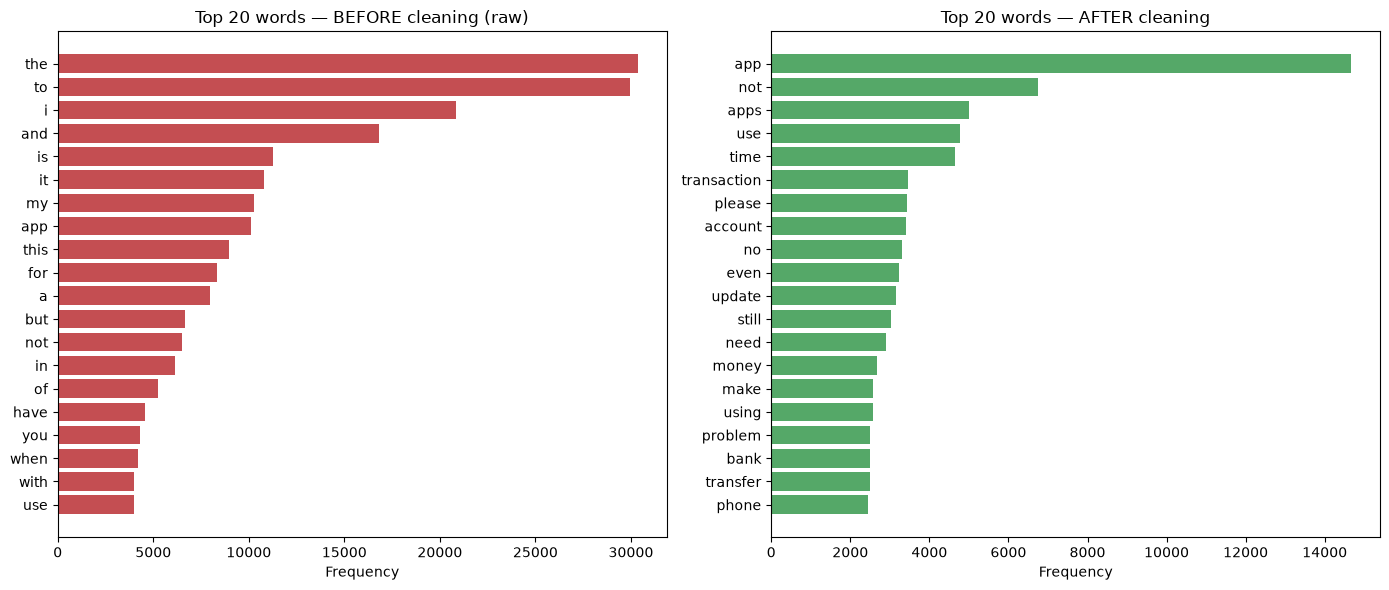

In [17]:
# Before/after top-20 word frequency.
def top_words(series_of_text, n=20):
    c = Counter()
    for txt in series_of_text:
        c.update(str(txt).lower().split())
    return c.most_common(n)

before = top_words(df["content"])     # raw
after = top_words(df["cleaned_text"]) # cleaned

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, data, title, color in [
    (axes[0], before, "Top 20 words — BEFORE cleaning (raw)", "#C44E52"),
    (axes[1], after, "Top 20 words — AFTER cleaning", "#55A868"),
]:
    words, counts = zip(*data)
    ax.barh(range(len(words)), counts, color=color)
    ax.set_yticks(range(len(words)))
    ax.set_yticklabels(words)
    ax.invert_yaxis()
    ax.set_title(title)
    ax.set_xlabel("Frequency")
plt.tight_layout()
plt.savefig(os.path.join(ROOT, "notebooks", "word_freq_before_after.png"), dpi=120)
plt.show()

In [18]:
# Compute summary numbers for the report.
lang_after = out["original_text"].apply(_lang_bucket).value_counts(normalize=True).mul(100).round(1)
class_bal = out["sentiment_label"].value_counts()
class_pct = out["sentiment_label"].value_counts(normalize=True).mul(100).round(1)

print("ROWS:")
print(f"  raw                 : {n_start}")
print(f"  after de-duplication: {n_after_dupes}")
print(f"  after <3-token drop : {n_after_short}")
print(f"  final saved         : {len(out)}")
print("\nCLASS BALANCE:")
for k in class_bal.index:
    print(f"  {k:>9}: {class_bal[k]:>6}  ({class_pct[k]}%)")
print("\nLANGUAGE MIX (heuristic):")
for k, v in lang_after.items():
    print(f"  {k:>22}: {v}%")

ROWS:
  raw                 : 18000
  after de-duplication: 17442
  after <3-token drop : 16882
  final saved         : 16882

CLASS BALANCE:
   negative:  13068  (77.4%)
   positive:   2740  (16.2%)
    neutral:   1074  (6.4%)

LANGUAGE MIX (heuristic):
            english_only: 97.9%
   code_mixed (Manglish): 2.1%
           malay_present: 0.0%
                   empty: 0.0%
